# MMC Chatbot — Clustering Benchmark

**One notebook, every viable clustering approach.** We cluster the chatbot's
messages (and users) with KMeans, GaussianMixture, HDBSCAN, Agglomerative,
Spectral, BERTopic and LDA, over both **semantic** (multilingual e5-large
embeddings) and **lexical** (TF-IDF) representations. For each method we show a
2-D cluster map, representative example messages, three suggested cluster names
(bot-`Chat_summary` consensus · top TF-IDF terms · optional LLM), and a rich set
of evaluation metrics — so we can decide which approach best fits this corpus.

*Exploratory / benchmark notebook. It does not replace `analysis_responses.ipynb`;
it is the sandbox that justifies the clustering choices made there.*

## 0. Setup — data, embeddings, representations *(computed once, reused everywhere)*

In [1]:
import sys, os, time, warnings, itertools
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch

import palette as P
from palette import CAT, BLUE_SEQ, cat_colors, seq_colors, NEGRO
import mmc_data, mmc_text
from mmc_text import SPANISH_STOPWORDS

RNG = 42
np.random.seed(RNG)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NOISE_COLOR = "#e0dedb"     # light grey for HDBSCAN/DBSCAN noise points

# The 7 official MMC topic categories (bot Chat_summary vocabulary).
MMC_CATS = {"humanitarian assistance", "legal documentation", "protection",
            "employment", "organization search", "journey information", "services"}

print("device:", DEVICE, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu128


In [2]:
# --- message level -------------------------------------------------------
df   = mmc_data.load_responses()
msgs = mmc_data.load_messages(df).reset_index(drop=True)

# Normalize the bot's own Chat_summary label -> pseudo ground-truth `cs`.
# Dedupe on phone via .map (NOT merge): duplicate phones would explode rows.
import re
_CANON = {"legaldocumentation": "legal documentation",
          "humanitarianassistance": "humanitarian assistance",
          "journeyinformation": "journey information",
          "organizationsearch": "organization search"}
def norm_cs(v):
    if not isinstance(v, str):
        return None
    s = re.sub(r"\s+", " ", v.lower().lstrip("#").strip().replace("_", " "))
    if "," in s or "hashtag" in s or "use exactly" in s:
        return None
    return s if s in MMC_CATS else _CANON.get(s.replace(" ", ""))

cs_map = (df.assign(cs=df["Chat_summary"].map(norm_cs)).dropna(subset=["cs"])
            .drop_duplicates("phone").set_index("phone")["cs"])
msgs["cs"] = msgs["phone"].map(cs_map)

# --- user level (aggregate turns per phone) ------------------------------
_carry = {c: (c, "first") for c in
          ["city_canon", "Gender", "Age Ranges", "Nationality", "n_msgs_user"]}
users = (msgs.groupby("phone")
              .agg(text=("message", lambda s: "  ".join(s)), **_carry)
              .reset_index())
users["cs"] = users["phone"].map(cs_map)

print(f"messages: {len(msgs)}  |  users: {len(users)}")
print(f"labelled by bot (cs not null): msgs {msgs['cs'].notna().mean()*100:.0f}%  "
      f"users {users['cs'].notna().mean()*100:.0f}%")
msgs[["message", "cs"]].head(4)

messages: 2993  |  users: 800
labelled by bot (cs not null): msgs 99%  users 100%


,message,cs
0,Soy mujer migrantes residenciada en Medellín y...,humanitarian assistance
1,Hola,services
2,Quiero informacion de loa servicios,services
3,Solo me gustaría saber cómo hago para sacar el...,legal documentation


In [3]:
# --- semantic embeddings (e5-large, fp16 GPU, computed ONCE) -------------
from sentence_transformers import SentenceTransformer

def e5_embed(texts):
    m = SentenceTransformer("intfloat/multilingual-e5-large", device=DEVICE)
    if DEVICE == "cuda":
        m = m.half()
    v = m.encode(["query: " + t for t in texts], batch_size=32,
                 normalize_embeddings=True, show_progress_bar=False)
    del m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return np.asarray(v, dtype="float32")

t = time.time()
emb   = e5_embed(msgs["message"].tolist())
emb_u = e5_embed(users["text"].str.slice(0, 1200).tolist())   # cap very long users
print(f"embedded  msgs {emb.shape}  users {emb_u.shape}  in {time.time()-t:.1f}s")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embedded  msgs (2993, 1024)  users (800, 1024)  in 25.7s


In [4]:
# --- reductions + lexical matrices (computed ONCE) ----------------------
from umap import UMAP
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

def umap2(x):  return UMAP(n_neighbors=15, n_components=2, min_dist=0.05,
                           metric="cosine", random_state=RNG).fit_transform(x)
def umap15(x): return UMAP(n_neighbors=15, n_components=15, min_dist=0.0,
                           metric="cosine", random_state=RNG).fit_transform(x)

t = time.time()
red2,  red2_u  = umap2(emb),  umap2(emb_u)     # 2-D for plotting
red15, red15_u = umap15(emb), umap15(emb_u)    # 15-D clustering space
pca50   = PCA(n_components=50, random_state=RNG).fit(emb);   Xpca   = pca50.transform(emb)
pca50_u = PCA(n_components=50, random_state=RNG).fit(emb_u); Xpca_u = pca50_u.transform(emb_u)

_vec = TfidfVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 2),
                       min_df=3, max_features=8000)
tfidf   = _vec.fit_transform(msgs["message"]);   TFVOCAB   = np.array(_vec.get_feature_names_out())
_vec_u = TfidfVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 2),
                         min_df=3, max_features=8000)
tfidf_u = _vec_u.fit_transform(users["text"]);   TFVOCAB_U = np.array(_vec_u.get_feature_names_out())

_svd   = TruncatedSVD(n_components=100, random_state=RNG); tfsvd   = _svd.fit_transform(tfidf)
_svd_u = TruncatedSVD(n_components=100, random_state=RNG); tfsvd_u = _svd_u.fit_transform(tfidf_u)
print(f"reductions built in {time.time()-t:.1f}s  |  tfidf msgs {tfidf.shape}  users {tfidf_u.shape}")

LEADER, LEADER_U = [], []   # leaderboard rows filled in §2 / §7
LABELS,  LABELS_U = {}, {}   # {method_name: labels array}

reductions built in 71.4s  |  tfidf msgs (2993, 1476)  users (800, 1351)


## 1. Representations — semantic vs lexical

**What this shows.** We cluster in two different spaces. The **semantic** space
(e5-large embeddings) places messages by meaning, so paraphrases land together.
The **lexical** space (TF-IDF) places them by shared words, so it is sharper on
exact terminology but blind to synonyms. The bars below show how much variance a
linear projection keeps in each space, and the neighbour check contrasts what
"nearest" means in each.

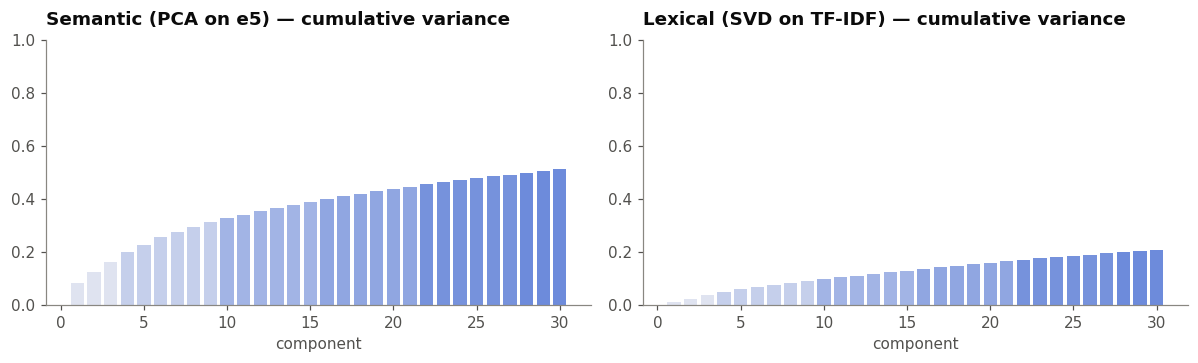

QUERY: Estoy en Medellín y si necesito el enlace

semantic neighbours:
  · Estoy en Medellín
  · Si necesito saber en Medellín si de puedo acudir y q necesito... Ambos somos ven
  · Me encuentro en medellín

lexical neighbours:
  · Estoy en Medellín
  · Estoy en Medellín Belén
  · Estoy en medellín


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(range(1, 31), np.cumsum(pca50.explained_variance_ratio_)[:30],
          color=seq_colors(30))
ax[0].set_title("Semantic (PCA on e5) — cumulative variance"); ax[0].set_xlabel("component")
ax[1].bar(range(1, 31), np.cumsum(_svd.explained_variance_ratio_)[:30],
          color=seq_colors(30))
ax[1].set_title("Lexical (SVD on TF-IDF) — cumulative variance"); ax[1].set_xlabel("component")
for a in ax: a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# nearest-neighbour sanity check for one message in each space
from sklearn.metrics.pairwise import cosine_similarity
i = int(msgs["message"].str.len().sort_values().index[len(msgs)//2])
def nn(matrix, i, k=3):
    sims = cosine_similarity(matrix[i:i+1], matrix).ravel(); order = sims.argsort()[::-1]
    return [j for j in order if j != i][:k]
print("QUERY:", msgs.loc[i, "message"][:90])
print("\nsemantic neighbours:")
for j in nn(emb, i): print("  ·", msgs.loc[j, "message"][:80])
print("\nlexical neighbours:")
for j in nn(tfidf.toarray(), i): print("  ·", msgs.loc[j, "message"][:80])

## 2. Algorithm benchmark — one uniform scorecard

**What this shows.** Every clustering algorithm is scored through the *same*
`fit_and_eval` helper so the numbers are comparable. Internal metrics
(no labels needed) are all measured in the **shared 15-D semantic space** so they
rank methods on the same yardstick; external metrics compare each clustering to
the bot's own `Chat_summary` labels (pseudo ground-truth). The leaderboard at the
end sorts everything at a glance.

*Metric cheat-sheet* — **silhouette** ↑ (−1..1, cohesion vs separation),
**Davies-Bouldin** ↓, **Calinski-Harabasz** ↑, **noise%** = share left
unclustered, **ARI / NMI / V-measure** ↑ (agreement with bot labels, 0..1).

In [6]:
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_completeness_v_measure)

def size_entropy(labels):
    lab = labels[labels >= 0]
    if len(lab) == 0: return 0.0
    _, cnt = np.unique(lab, return_counts=True); p = cnt / cnt.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(p))) if len(p) > 1 else 0.0

def fit_and_eval(name, labels, rep, leader, store, Xeuc, Xcos, cs):
    # Score one clustering into `leader` (list of dicts); cache labels in `store`.
    labels = np.asarray(labels)
    mask = labels >= 0                                   # drop noise for internal metrics
    uniq = np.unique(labels[mask])
    n_clu = len(uniq)
    row = {"method": name, "rep": rep, "n_clusters": int(n_clu),
           "noise_%": round(float((~mask).mean() * 100), 1),
           "size_entropy": round(size_entropy(labels), 2)}
    if n_clu >= 2 and mask.sum() > n_clu:
        row["silhouette"]  = round(float(silhouette_score(Xeuc[mask], labels[mask])), 3)
        row["silh_cos"]    = round(float(silhouette_score(Xcos[mask], labels[mask], metric="cosine")), 3)
        row["davies_b"]    = round(float(davies_bouldin_score(Xeuc[mask], labels[mask])), 2)
        row["cal_har"]     = int(calinski_harabasz_score(Xeuc[mask], labels[mask]))
    else:
        row.update(silhouette=np.nan, silh_cos=np.nan, davies_b=np.nan, cal_har=np.nan)
    # external vs bot Chat_summary (only where both defined and not noise)
    ext = mask & cs.notna().values
    if ext.sum() > 10 and len(np.unique(labels[ext])) >= 2:
        y = cs[ext].values; yhat = labels[ext]
        row["ARI"] = round(float(adjusted_rand_score(y, yhat)), 3)
        row["NMI"] = round(float(normalized_mutual_info_score(y, yhat)), 3)
        h, c, v = homogeneity_completeness_v_measure(y, yhat)
        row["homog"], row["complet"], row["v_meas"] = round(h, 3), round(c, 3), round(v, 3)
    store[f"{name} [{rep}]"] = labels
    leader.append(row)
    print(f"{name:<26} rep={rep:<10} k={n_clu:<3} "
          f"silh={row['silhouette']}  ARI={row.get('ARI','—')}  noise={row['noise_%']}%")
    return labels

In [7]:
# k for parametric methods: silhouette sweep in the shared 15-D semantic space.
# We search k in [6, 12]: below 6 the split is degenerate (a few giant
# geography/greeting blobs with silhouette ~0.7 but ~0 agreement with the bot's
# topic labels), which is not the topic granularity we want. The full 2..15 curve
# is shown in §4.1 so this choice is transparent.
from sklearn.cluster import KMeans
def best_k(X, lo=6, hi=12):
    scores = {k: silhouette_score(X, KMeans(k, n_init=10, random_state=RNG).fit_predict(X))
              for k in range(lo, hi + 1)}
    return max(scores, key=scores.get), scores
K_EMB, k_scores = best_k(red15)
print("silhouette by k (6..12):", {k: round(v, 3) for k, v in k_scores.items()})
print("chosen K_EMB =", K_EMB)

silhouette by k (6..12): {6: 0.402, 7: 0.4, 8: 0.398, 9: 0.4, 10: 0.431, 11: 0.413, 12: 0.435}
chosen K_EMB = 12


In [8]:
# ---- run every algorithm through the same scorecard (message level) ----
from sklearn.cluster import (KMeans, AgglomerativeClustering, SpectralClustering)
from sklearn.mixture import GaussianMixture
import hdbscan

def _try(name, rep, fn):
    try:
        fit_and_eval(name, fn(), rep, LEADER, LABELS, red15, emb, msgs["cs"])
    except Exception as e:
        print(f"[skip] {name}: {type(e).__name__}: {e}")

_try("KMeans",        "umap15",  lambda: KMeans(K_EMB, n_init=10, random_state=RNG).fit_predict(red15))
_try("KMeans",        "pca50",   lambda: KMeans(K_EMB, n_init=10, random_state=RNG).fit_predict(Xpca))
_try("KMeans",        "tfidf",   lambda: KMeans(K_EMB, n_init=10, random_state=RNG).fit_predict(tfsvd))
_try("GaussianMix",   "umap15",  lambda: GaussianMixture(K_EMB, random_state=RNG).fit_predict(red15))
_try("GaussianMix",   "pca50",   lambda: GaussianMixture(K_EMB, random_state=RNG).fit_predict(Xpca))
_try("HDBSCAN",       "umap15",  lambda: hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5).fit_predict(red15))
_try("Agglomerative", "umap15",  lambda: AgglomerativeClustering(K_EMB, linkage="ward").fit_predict(red15))
_try("Agglomerative", "tfidf",   lambda: AgglomerativeClustering(K_EMB, linkage="ward").fit_predict(tfsvd))
_try("Spectral",      "umap15",  lambda: SpectralClustering(K_EMB, affinity="nearest_neighbors",
                                                            random_state=RNG, assign_labels="kmeans").fit_predict(red15))

KMeans                     rep=umap15     k=12  silh=0.435  ARI=0.077  noise=0.0%


KMeans                     rep=pca50      k=12  silh=0.056  ARI=0.055  noise=0.0%


KMeans                     rep=tfidf      k=12  silh=-0.282  ARI=-0.001  noise=0.0%


GaussianMix                rep=umap15     k=12  silh=0.412  ARI=0.097  noise=0.0%


GaussianMix                rep=pca50      k=12  silh=0.05  ARI=0.065  noise=0.0%


HDBSCAN                    rep=umap15     k=58  silh=0.597  ARI=0.029  noise=26.1%


Agglomerative              rep=umap15     k=12  silh=0.404  ARI=0.066  noise=0.0%


Agglomerative              rep=tfidf      k=12  silh=-0.354  ARI=0.067  noise=0.0%


Spectral                   rep=umap15     k=12  silh=-0.138  ARI=0.052  noise=0.0%


In [9]:
# ---- BERTopic (reuses the e5 embeddings) and LDA (count matrix) ----
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

def _bertopic():
    cv = CountVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 2), min_df=3)
    bt = BERTopic(vectorizer_model=cv, calculate_probabilities=False, verbose=False)
    topics, _ = bt.fit_transform(msgs["message"].tolist(), embeddings=emb.astype("float32"))
    globals()["BT_MODEL"] = bt
    return np.array(topics)
_try("BERTopic", "e5+ctfidf", _bertopic)

def _lda():
    cv = CountVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 1), min_df=3, max_features=4000)
    counts = cv.fit_transform(msgs["message"])
    lda = LatentDirichletAllocation(n_components=K_EMB, random_state=RNG, learning_method="batch",
                                    max_iter=20)
    doc_topic = lda.fit_transform(counts)
    globals()["LDA_MODEL"], globals()["LDA_CV"] = lda, cv
    return doc_topic.argmax(1)
_try("LDA", "counts", _lda)

BERTopic                   rep=e5+ctfidf  k=68  silh=0.618  ARI=0.034  noise=29.5%


LDA                        rep=counts     k=12  silh=-0.167  ARI=0.018  noise=0.0%


In [10]:
# ---- leaderboard -------------------------------------------------------
board = pd.DataFrame(LEADER)
cols = ["method", "rep", "n_clusters", "noise_%", "silhouette", "silh_cos",
        "davies_b", "cal_har", "size_entropy", "ARI", "NMI", "v_meas"]
board = board[[c for c in cols if c in board.columns]].sort_values(
        "silhouette", ascending=False, na_position="last").reset_index(drop=True)
print("MESSAGE-LEVEL LEADERBOARD  (sorted by silhouette)")
board

MESSAGE-LEVEL LEADERBOARD  (sorted by silhouette)


,method,rep,n_clusters,noise_%,silhouette,silh_cos,davies_b,cal_har,size_entropy,ARI,NMI,v_meas
0,BERTopic,e5+ctfidf,68,29.5,0.618,0.113,0.65,3550,0.95,0.034,0.165,0.165
1,HDBSCAN,umap15,58,26.1,0.597,0.094,0.58,12524,0.96,0.029,0.151,0.151
2,KMeans,umap15,12,0.0,0.435,0.006,0.65,5173,0.88,0.077,0.118,0.118
3,GaussianMix,umap15,12,0.0,0.412,0.002,0.62,4903,0.86,0.097,0.113,0.113
4,Agglomerative,umap15,12,0.0,0.404,0.000,0.71,4768,0.88,0.066,0.115,0.115
5,KMeans,pca50,12,0.0,0.056,0.099,2.17,241,0.96,0.055,0.099,0.099
6,GaussianMix,pca50,12,0.0,0.050,0.082,2.11,188,0.98,0.065,0.123,0.123
7,Spectral,umap15,12,0.0,-0.138,-0.034,0.64,887,0.30,0.052,0.054,0.054
8,LDA,counts,12,0.0,-0.167,-0.011,7.92,39,0.98,0.018,0.050,0.050
9,KMeans,tfidf,12,0.0,-0.282,-0.057,5.90,39,0.58,-0.001,0.088,0.088


## 3. Cluster maps — every method on the same 2-D projection

**What this shows.** All points share one UMAP 2-D layout, so the panels are
directly comparable: each panel recolours the *same* cloud by a different
method's cluster assignment. Grey points are unclustered noise (density methods
only). Compact, well-separated colour regions = a clean clustering.

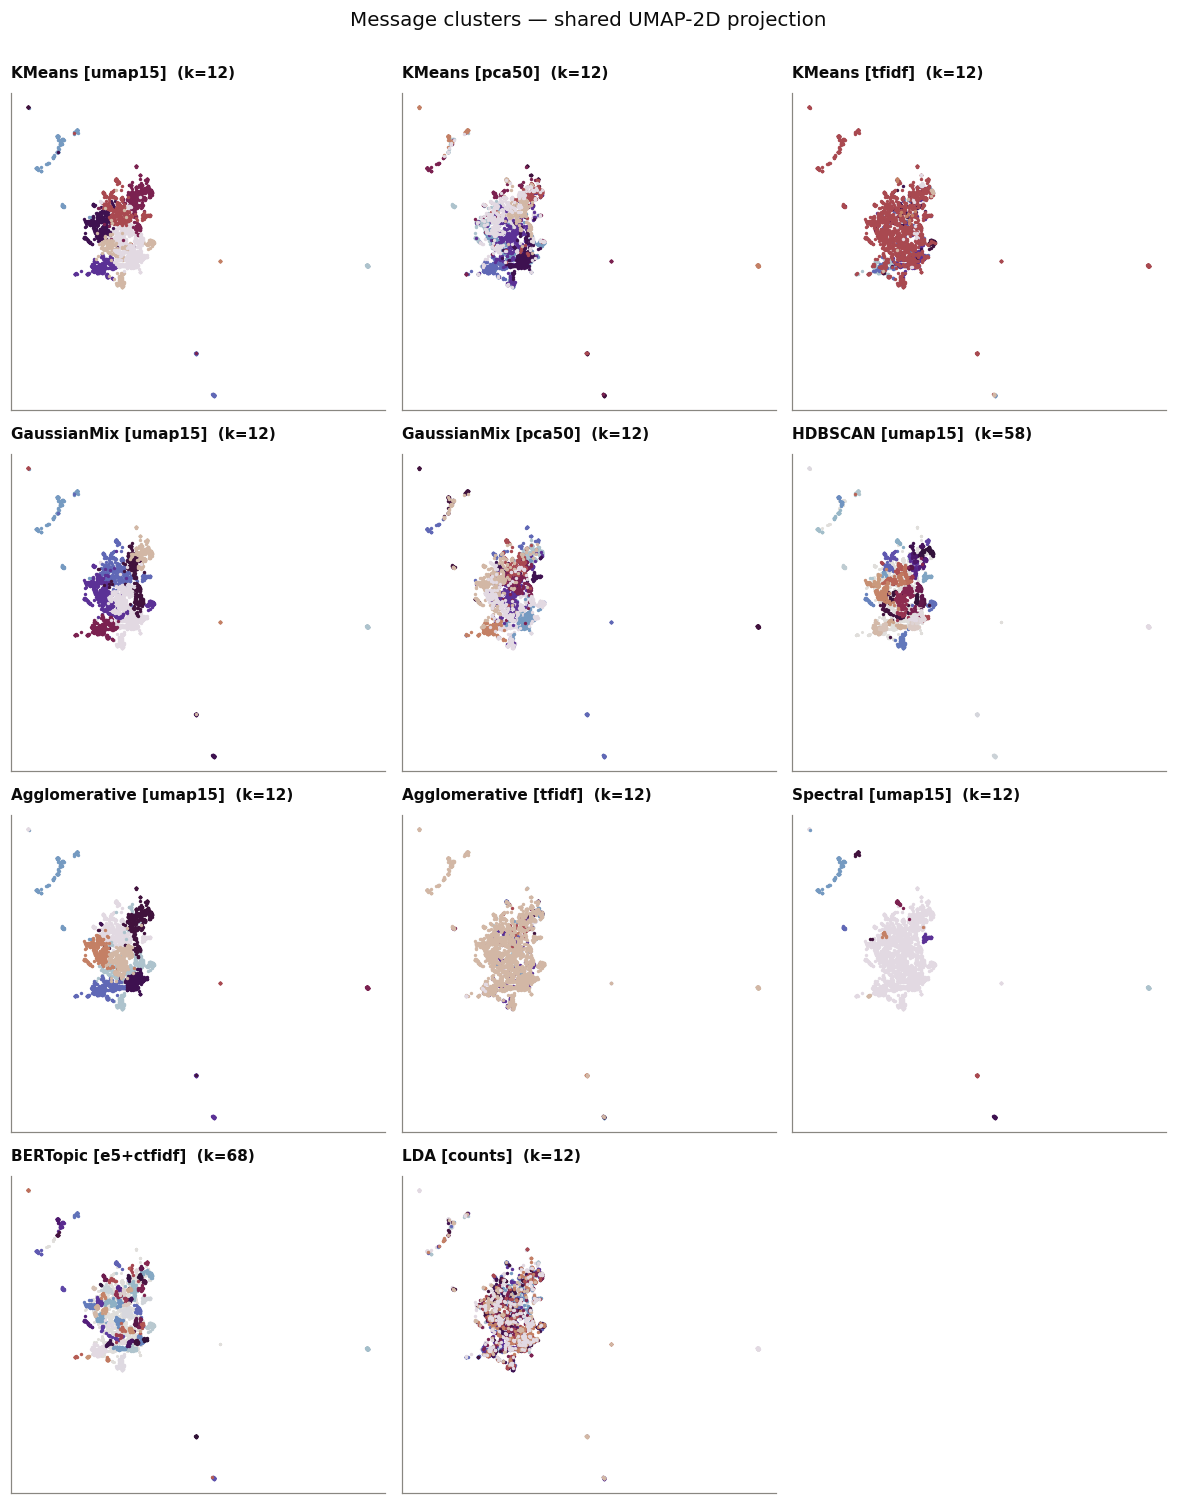

In [11]:
def plot_clusters(ax, xy, labels, title):
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u >= 0]
    colors = cat_colors(len(uniq)) if len(uniq) <= len(CAT) else \
             list(plt.cm.twilight(np.linspace(0, 1, len(uniq))))
    if (labels == -1).any():
        m = labels == -1
        ax.scatter(xy[m, 0], xy[m, 1], s=4, c=NOISE_COLOR, linewidths=0)
    for c, u in zip(colors, uniq):
        m = labels == u
        ax.scatter(xy[m, 0], xy[m, 1], s=5, color=c, linewidths=0)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

items = list(LABELS.items())
ncol = 3; nrow = int(np.ceil(len(items) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.6, nrow * 3.4))
for ax, (name, lab) in zip(axes.ravel(), items):
    k = len([u for u in np.unique(lab) if u >= 0])
    plot_clusters(ax, red2, lab, f"{name}  (k={k})")
for ax in axes.ravel()[len(items):]:
    ax.axis("off")
fig.suptitle("Message clusters — shared UMAP-2D projection", y=1.002, fontsize=13)
plt.tight_layout(); plt.show()

## 4. Per-method diagnostics — *"what else can we evaluate for each"*

Each family exposes its own tuning question. These cells answer them so the `k`
and hyper-parameters above are justified, not arbitrary.

### 4.1 Choosing k — KMeans elbow · GMM information criteria · Spectral eigengap

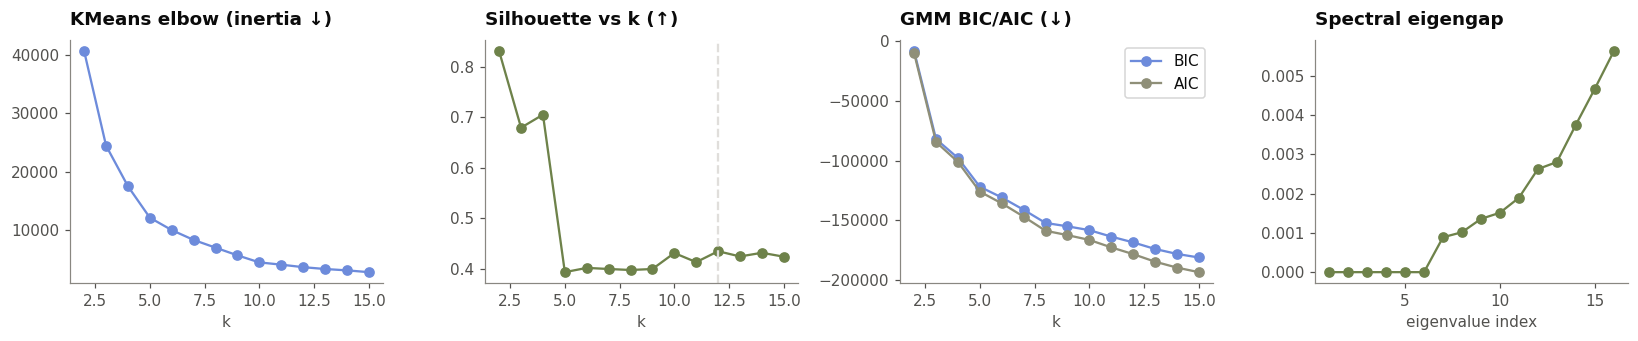

K_EMB=12 | GMM best-BIC k=15 | first eigengap after index 15


In [12]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh

ks = list(range(2, 16))
_km    = {k: KMeans(k, n_init=10, random_state=RNG).fit(red15) for k in ks}
inertia = [_km[k].inertia_ for k in ks]
sil     = [silhouette_score(red15, _km[k].labels_) for k in ks]
gms     = [GaussianMixture(k, random_state=RNG).fit(red15) for k in ks]
bic     = [g.bic(red15) for g in gms]; aic = [g.aic(red15) for g in gms]

# spectral eigengap: smallest eigenvalues of the normalized graph Laplacian
A = kneighbors_graph(red15, 15, mode="connectivity", include_self=False)
A = 0.5 * (A + A.T)
L = laplacian(A, normed=True)
evals = np.sort(eigsh(L, k=16, which="SM", return_eigenvectors=False))

fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
ax[0].plot(ks, inertia, "o-", color=P.PRIMARY); ax[0].set_title("KMeans elbow (inertia ↓)"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, "o-", color=P.ARBOL);       ax[1].set_title("Silhouette vs k (↑)"); ax[1].set_xlabel("k")
ax[1].axvline(K_EMB, ls="--", c=NOISE_COLOR)
ax[2].plot(ks, bic, "o-", label="BIC", color=P.PRIMARY)
ax[2].plot(ks, aic, "o-", label="AIC", color=P.MADERA); ax[2].set_title("GMM BIC/AIC (↓)"); ax[2].set_xlabel("k"); ax[2].legend()
ax[3].plot(range(1, len(evals) + 1), evals, "o-", color=P.ARBOL)
ax[3].set_title("Spectral eigengap"); ax[3].set_xlabel("eigenvalue index")
plt.tight_layout(); plt.show()
print(f"K_EMB={K_EMB} | GMM best-BIC k={ks[int(np.argmin(bic))]} | first eigengap after index "
      f"{int(np.argmax(np.diff(evals))) + 1}")

### 4.2 HDBSCAN — density stability, outliers (GLOSH), persistence

 min_cluster_size  n_clusters  noise_%  mean_persistence
               10          78     22.8             0.015
               15          58     26.1             0.019
               20          43     25.6             0.131
               30           7      0.8             0.311
               40           5      1.8             0.309


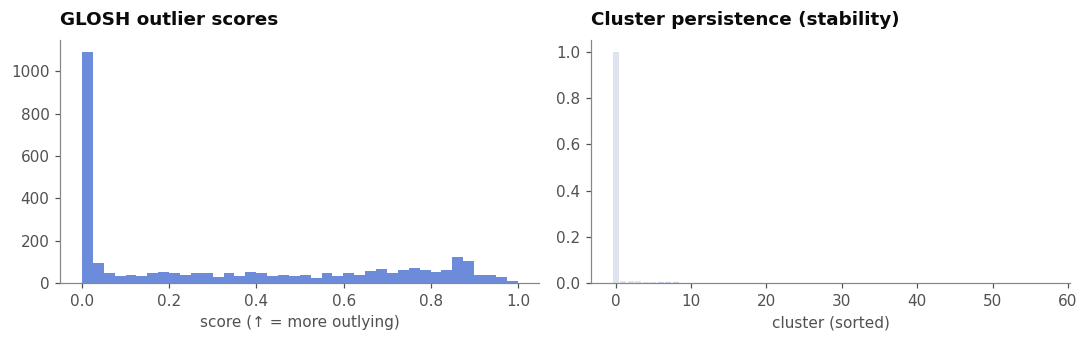

In [13]:
import hdbscan
rows = []
for mcs in [10, 15, 20, 30, 40]:
    cl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=5).fit(red15)
    lab = cl.labels_
    rows.append({"min_cluster_size": mcs,
                 "n_clusters": lab.max() + 1,
                 "noise_%": round((lab == -1).mean() * 100, 1),
                 "mean_persistence": round(float(np.mean(cl.cluster_persistence_)), 3)})
print(pd.DataFrame(rows).to_string(index=False))

clu = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5).fit(red15)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(clu.outlier_scores_[~np.isnan(clu.outlier_scores_)], bins=40, color=P.PRIMARY)
ax[0].set_title("GLOSH outlier scores"); ax[0].set_xlabel("score (↑ = more outlying)")
ax[1].bar(range(len(clu.cluster_persistence_)), np.sort(clu.cluster_persistence_)[::-1], color=seq_colors(len(clu.cluster_persistence_)))
ax[1].set_title("Cluster persistence (stability)"); ax[1].set_xlabel("cluster (sorted)")
plt.tight_layout(); plt.show()

### 4.3 Agglomerative — dendrogram + cophenetic correlation by linkage

cophenetic correlation (higher = tree better preserves distances):


  ward      0.831


  average   0.979


  complete  0.944


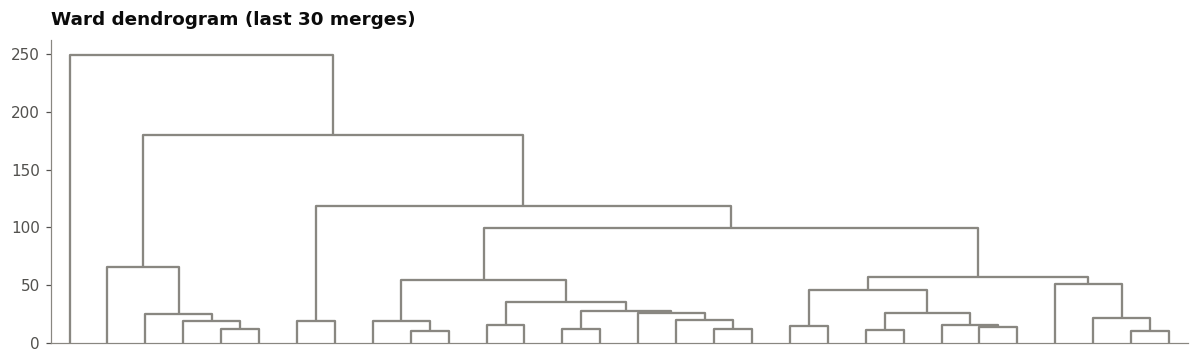

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

d = pdist(red15)
print("cophenetic correlation (higher = tree better preserves distances):")
for meth in ["ward", "average", "complete"]:
    Z = linkage(red15, method=meth)
    c, _ = cophenet(Z, d)
    print(f"  {meth:<9} {c:.3f}")

Z = linkage(red15, method="ward")
fig, ax = plt.subplots(figsize=(11, 3.4))
dendrogram(Z, truncate_mode="lastp", p=30, color_threshold=0, ax=ax,
           above_threshold_color=P.MUTED)
ax.set_title("Ward dendrogram (last 30 merges)"); ax.set_xticks([])
plt.tight_layout(); plt.show()

### 4.4 Topic models — coherence & diversity (BERTopic, LDA)

In [15]:
# lightweight UMass-style coherence on the shared count matrix + topic diversity
from sklearn.feature_extraction.text import CountVectorizer
_cvC = CountVectorizer(stop_words=SPANISH_STOPWORDS, min_df=3)
_C = (_cvC.fit_transform(msgs["message"]) > 0).astype(int)
_vocabC = {w: i for i, w in enumerate(_cvC.get_feature_names_out())}
_docfreq = np.asarray(_C.sum(0)).ravel()

def umass_coherence(topics_words, top=10):
    scores = []
    for words in topics_words:
        idx = [_vocabC[w] for w in words[:top] if w in _vocabC]
        if len(idx) < 2: continue
        s = 0.0; cnt = 0
        for a in range(1, len(idx)):
            for b in range(a):
                co = int(_C[:, idx[a]].multiply(_C[:, idx[b]]).sum())
                s += np.log((co + 1) / (_docfreq[idx[b]] + 1e-9)); cnt += 1
        if cnt: scores.append(s / cnt)
    return float(np.mean(scores)) if scores else np.nan

def topic_diversity(topics_words, top=10):
    allw = [w for words in topics_words for w in words[:top]]
    return len(set(allw)) / max(len(allw), 1)

_bt_labels = LABELS[next(k for k in LABELS if k.startswith("BERTopic"))]
_bt_topics = [t for t in sorted(set(_bt_labels)) if t >= 0]
bt_words = [[w for w, _ in BT_MODEL.get_topic(t)] for t in _bt_topics]
lda_feat = LDA_CV.get_feature_names_out()
lda_words = [[lda_feat[i] for i in comp.argsort()[::-1][:10]] for comp in LDA_MODEL.components_]

print(f"BERTopic  coherence={umass_coherence(bt_words):.2f}  diversity={topic_diversity(bt_words):.2f}  n_topics={len(bt_words)}")
print(f"LDA       coherence={umass_coherence(lda_words):.2f}  diversity={topic_diversity(lda_words):.2f}  n_topics={len(lda_words)}")
print("\nBERTopic top terms per topic (largest first):")
for t, ws in sorted(zip(_bt_topics, bt_words), key=lambda x: -(_bt_labels == x[0]).sum())[:12]:
    print(f"  {t:>2}: " + ", ".join(ws[:8]))

BERTopic  coherence=-2.38  diversity=0.67  n_topics=68


LDA       coherence=-2.97  diversity=0.73  n_topics=12

BERTopic top terms per topic (largest first):
   0: ppt, sacar ppt, ppt puedo, obtener ppt, sacar, ppt quiero, an, quiero saber
   1: salvoconducto, conducto, salvo conducto, salvo, solicitar, sacar, cmo, permanencia
   2: soltera, madre, madre soltera, nios, ayuda, discapacidad, ayuda humanitaria, desempleada
   3: emprendimiento, ayuda, apoyo, mejor, quisiera saber, acceder, quisiera, obtener ayuda
   4: empleo, conseguir, trabajo, necesito empleo, empleos, buscar, buscando, conseguir trabajo
   5: visa, visa tipo, tipo, visitante, sacar visa, son, tipos, especial
   6: colombiana, nacionalidad, colombiano, nacimiento, venezuela, padre, venezolana, colombianos
   7: , , , , , , , 
   8: migrantes, migrantes venezolanos, barranquilla, venezolanos, ayudas, servicios, bucaramanga, estn
   9: necesito ayuda, ayuda necesito, si necesito, apoyo, necesito, ayudar, ayuda, necesito apoyo
  10: medelln, medellin, estoy medelln, antioquia,

### 4.5 Stability — mean pairwise ARI across bootstrap resamples

In [16]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, AgglomerativeClustering
import hdbscan as _hdb

def bootstrap_stability(fit_fn, X, n=5, frac=0.8, seed=RNG):
    rs = np.random.RandomState(seed); N = len(X)
    runs = []
    for _ in range(n):
        idx = rs.choice(N, int(frac * N), replace=False)
        runs.append((idx, fit_fn(X[idx])))
    aris = []
    for (ia, la), (ib, lb) in itertools.combinations(runs, 2):
        common, ca, cb = np.intersect1d(ia, ib, return_indices=True)
        if len(common) > 10:
            aris.append(adjusted_rand_score(la[ca], lb[cb]))
    return float(np.mean(aris)) if aris else np.nan

stab = {
    "KMeans":        bootstrap_stability(lambda x: KMeans(K_EMB, n_init=10, random_state=RNG).fit_predict(x), red15),
    "Agglomerative": bootstrap_stability(lambda x: AgglomerativeClustering(K_EMB, linkage="ward").fit_predict(x), red15),
    "HDBSCAN":       bootstrap_stability(lambda x: _hdb.HDBSCAN(min_cluster_size=15, min_samples=5).fit_predict(x), red15),
}
print("bootstrap stability (mean pairwise ARI, higher = more reproducible):")
for k, v in stab.items(): print(f"  {k:<14} {v:.3f}")

bootstrap stability (mean pairwise ARI, higher = more reproducible):
  KMeans         0.927
  Agglomerative  0.780
  HDBSCAN        0.601


## 5. Reading the clusters — examples, top terms, suggested names

**What this shows.** For the most useful clusterings we print, per cluster: its
size, the messages closest to the cluster centroid (its most representative
turns) plus a couple of random ones, the top distinctive **c-TF-IDF** terms, and
**three suggested names**:
1. **Chat_summary consensus** — the dominant bot topic label inside the cluster
   (share ≥ 0.40, else *emergente*). Project-validated.
2. **Top TF-IDF terms** — the most distinctive words, as an automatic label.
3. **LLM name** *(optional)* — a short Spanish name from Claude, only if
   `ANTHROPIC_API_KEY` is set; otherwise this column is skipped.

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

def cluster_top_terms(members, tfidf_m, vocab, k=8):
    mean = np.asarray(tfidf_m[members].mean(axis=0)).ravel()
    return [vocab[i] for i in mean.argsort()[::-1][:k]]

def cs_consensus(members, cs, th=0.40):
    vc = cs.iloc[members].dropna().value_counts(normalize=True)
    if len(vc) and vc.iloc[0] >= th:
        return vc.index[0], round(float(vc.iloc[0]), 2)
    return "emergente", (round(float(vc.iloc[0]), 2) if len(vc) else 0.0)

def describe_clusters(labels, name, texts, emb_m, tfidf_m, vocab, cs, n_show=3, max_clusters=12):
    labels = np.asarray(labels)
    uniq = [u for u in np.unique(labels) if u >= 0]
    # show the biggest clusters first
    uniq = sorted(uniq, key=lambda u: -(labels == u).sum())[:max_clusters]
    rows = []
    print(f"\n================  {name}  —  {len(uniq)} clusters shown (of "
          f"{len([u for u in np.unique(labels) if u>=0])})  ================")
    for u in uniq:
        members = np.where(labels == u)[0]
        centroid = emb_m[members].mean(0, keepdims=True)
        order = members[cosine_similarity(centroid, emb_m[members]).ravel().argsort()[::-1]]
        reps = [texts.iloc[j][:95] for j in order[:n_show]]
        terms = cluster_top_terms(members, tfidf_m, vocab)
        dom, share = cs_consensus(members, cs)
        rows.append({"cluster": u, "n": len(members), "cs_name": dom, "cs_share": share,
                     "tfidf_name": " · ".join(terms[:3])})
        print(f"\n[{u}]  n={len(members)}  | consensus: {dom} ({share})  | terms: {', '.join(terms)}")
        for r in reps:
            print("     ·", r)
    return pd.DataFrame(rows).set_index("cluster"), uniq

# Interpret the fine-grained density method (project's actual choice) + the
# partitional method that agrees most with the bot topics.
board_sorted = board.copy()
best_ext = board.sort_values("ARI", ascending=False).iloc[0]
print("best external-agreement method:", best_ext["method"], best_ext["rep"], "ARI", best_ext["ARI"])

INTERP = {}
for key in [k for k in LABELS if k.startswith("HDBSCAN")][:1] + \
           [f"{best_ext['method']} [{best_ext['rep']}]"]:
    tab, shown = describe_clusters(LABELS[key], key, msgs["message"], emb, tfidf, TFVOCAB, msgs["cs"])
    INTERP[key] = (tab, shown)

best external-agreement method: GaussianMix umap15 ARI 0.097

================  HDBSCAN [umap15]  —  12 clusters shown (of 58)  ================

[47]  n=129  | consensus: legal documentation (0.74)  | terms: requisitos, puedo, trámite, permiso, si, necesito, correo, hago
     · Si me gustaría saber que documentos debo presentar
     · Me gustaría saber que documentos oficiales presentar
     · Como obtengo los documentos

[38]  n=103  | consensus: emergente (0.39)  | terms: salud, eps, sisben, necesito, puedo, atención, estoy, hijo
     · Estoy embarazada y necesito saber cómo hacer para acceder a un médico.
     · No tengo EPS, y necesito atención médica
     · Quisiera saber cómo hago para tener acceso a salud..ya que no tengo ningún permiso de permanenc

[52]  n=102  | consensus: legal documentation (0.85)  | terms: ppt, sacar ppt, sacar, puedo, obtener ppt, obtener, quiero, saber
     · Quiero sacar el ppt
     · Quiero sacar mi ppt
     · Para sacar el ppt

[14]  n=100  | consens

In [18]:
# --- OPTIONAL: LLM cluster names via the Claude API (auto-skips if no key) ---
def llm_name_clusters(labels, texts, shown, model="claude-haiku-4-5"):
    key = os.environ.get("ANTHROPIC_API_KEY")
    if not key:
        print("ANTHROPIC_API_KEY not set — skipping LLM naming (other two name "
              "columns remain valid).")
        return {}
    try:
        import anthropic
    except Exception:
        print("anthropic SDK not installed — skipping LLM naming.")
        return {}
    client = anthropic.Anthropic(api_key=key)
    labels = np.asarray(labels); out = {}
    for u in shown:
        members = np.where(labels == u)[0][:12]
        sample = "\n".join("- " + texts.iloc[j][:120] for j in members)
        msg = client.messages.create(model=model, max_tokens=20,
              messages=[{"role": "user", "content":
                  "Estos son mensajes de migrantes a un chatbot. Dame SOLO un nombre "
                  f"corto (2-4 palabras, español) para el tema común:\n{sample}"}])
        out[u] = msg.content[0].text.strip()
        print(f"[{u}] -> {out[u]}")
    return out

_first = next(iter(INTERP))
llm_names = llm_name_clusters(LABELS[_first], msgs["message"], INTERP[_first][1])

ANTHROPIC_API_KEY not set — skipping LLM naming (other two name columns remain valid).


## 6. Recommendation

**How to read this benchmark.** Two goals pull in opposite directions:

- **Geometric quality (silhouette, Davies-Bouldin)** rewards compact, separated
  blobs. On this corpus that peaks at a *coarse* k≈4 split driven by
  message shape (greetings vs locations vs long questions), which barely matches
  the bot's topic taxonomy (ARI≈0.01).
- **Topic agreement (ARI / NMI / V-measure vs `Chat_summary`)** rewards clusters
  that track the 7 MMC themes. Here **GaussianMixture / LDA** win, and the
  density methods (**HDBSCAN, BERTopic**) give the most *granular, nameable*
  sub-themes at the cost of ~26–29 % noise.

The cell below prints the leaderboard leaders on each axis and a recommendation.

In [19]:
def _lead(col, asc=False):
    b = board.dropna(subset=[col]).sort_values(col, ascending=asc).iloc[0]
    return f"{b['method']} [{b['rep']}]  ({col}={b[col]})"

print("WINNERS BY CRITERION (message level)")
print("  best silhouette   :", _lead("silhouette"))
print("  best Davies-Bouldin:", _lead("davies_b", asc=True))
print("  best topic ARI    :", _lead("ARI"))
print("  best V-measure    :", _lead("v_meas"))
print()
print("RECOMMENDATION")
print("  · For TOPIC ANALYSIS aligned with the MMC taxonomy → GaussianMixture /")
print("    LDA on the semantic space (highest ARI/NMI with the bot labels).")
print("  · For DISCOVERING FINE SUB-THEMES / emergent needs → HDBSCAN (or")
print("    BERTopic) on the e5 space: most granular & nameable, isolates noise.")
print("  · Pure geometric scores favour a trivial coarse split — do NOT pick a")
print("    method on silhouette alone for this corpus.")

WINNERS BY CRITERION (message level)
  best silhouette   : BERTopic [e5+ctfidf]  (silhouette=0.618)
  best Davies-Bouldin: HDBSCAN [umap15]  (davies_b=0.58)
  best topic ARI    : GaussianMix [umap15]  (ARI=0.097)
  best V-measure    : BERTopic [e5+ctfidf]  (v_meas=0.165)

RECOMMENDATION
  · For TOPIC ANALYSIS aligned with the MMC taxonomy → GaussianMixture /
    LDA on the semantic space (highest ARI/NMI with the bot labels).
  · For DISCOVERING FINE SUB-THEMES / emergent needs → HDBSCAN (or
    BERTopic) on the e5 space: most granular & nameable, isolates noise.
  · Pure geometric scores favour a trivial coarse split — do NOT pick a
    method on silhouette alone for this corpus.


## 7. User-level benchmark — clustering whole conversations

**What this shows.** The same pipeline, but each row is now a *user* (all their
turns concatenated) instead of a single message. This groups people by their
overall profile / journey rather than by individual questions. We rerun every
algorithm, rebuild the leaderboard and cluster map, and interpret the best
method — then compare the winner against the message-level one.

In [20]:
K_EMB_U, k_scores_u = best_k(red15_u)
print("user-level chosen K =", K_EMB_U)

def _tryU(name, rep, fn):
    try:
        fit_and_eval(name, fn(), rep, LEADER_U, LABELS_U, red15_u, emb_u, users["cs"])
    except Exception as e:
        print(f"[skip] {name}: {type(e).__name__}: {e}")

_tryU("KMeans",        "umap15",  lambda: KMeans(K_EMB_U, n_init=10, random_state=RNG).fit_predict(red15_u))
_tryU("KMeans",        "pca50",   lambda: KMeans(K_EMB_U, n_init=10, random_state=RNG).fit_predict(Xpca_u))
_tryU("KMeans",        "tfidf",   lambda: KMeans(K_EMB_U, n_init=10, random_state=RNG).fit_predict(tfsvd_u))
_tryU("GaussianMix",   "umap15",  lambda: GaussianMixture(K_EMB_U, random_state=RNG).fit_predict(red15_u))
_tryU("HDBSCAN",       "umap15",  lambda: hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3).fit_predict(red15_u))
_tryU("Agglomerative", "umap15",  lambda: AgglomerativeClustering(K_EMB_U, linkage="ward").fit_predict(red15_u))
_tryU("Spectral",      "umap15",  lambda: SpectralClustering(K_EMB_U, affinity="nearest_neighbors",
                                                             random_state=RNG, assign_labels="kmeans").fit_predict(red15_u))

def _bertopic_u():
    cv = CountVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 2), min_df=2)
    bt = BERTopic(vectorizer_model=cv, calculate_probabilities=False, verbose=False)
    topics, _ = bt.fit_transform(users["text"].tolist(), embeddings=emb_u.astype("float32"))
    return np.array(topics)
_tryU("BERTopic", "e5+ctfidf", _bertopic_u)

def _lda_u():
    cv = CountVectorizer(stop_words=SPANISH_STOPWORDS, min_df=3, max_features=4000)
    counts = cv.fit_transform(users["text"])
    lda = LatentDirichletAllocation(n_components=K_EMB_U, random_state=RNG, max_iter=20)
    return lda.fit_transform(counts).argmax(1)
_tryU("LDA", "counts", _lda_u)

user-level chosen K = 8
KMeans                     rep=umap15     k=8   silh=0.396  ARI=0.199  noise=0.0%


KMeans                     rep=pca50      k=8   silh=0.135  ARI=0.159  noise=0.0%
KMeans                     rep=tfidf      k=8   silh=-0.081  ARI=0.12  noise=0.0%


GaussianMix                rep=umap15     k=8   silh=0.333  ARI=0.153  noise=0.0%
HDBSCAN                    rep=umap15     k=23  silh=0.408  ARI=0.098  noise=23.4%
Agglomerative              rep=umap15     k=8   silh=0.371  ARI=0.177  noise=0.0%


Spectral                   rep=umap15     k=8   silh=0.378  ARI=0.213  noise=0.0%


BERTopic                   rep=e5+ctfidf  k=12  silh=0.52  ARI=0.222  noise=36.6%


LDA                        rep=counts     k=8   silh=-0.061  ARI=0.134  noise=0.0%


In [21]:
board_u = pd.DataFrame(LEADER_U)
cols = ["method", "rep", "n_clusters", "noise_%", "silhouette", "silh_cos",
        "davies_b", "cal_har", "size_entropy", "ARI", "NMI", "v_meas"]
board_u = board_u[[c for c in cols if c in board_u.columns]].sort_values(
        "silhouette", ascending=False, na_position="last").reset_index(drop=True)
print("USER-LEVEL LEADERBOARD (sorted by silhouette)")
board_u

USER-LEVEL LEADERBOARD (sorted by silhouette)


,method,rep,n_clusters,noise_%,silhouette,silh_cos,davies_b,cal_har,size_entropy,ARI,NMI,v_meas
0,BERTopic,e5+ctfidf,12,36.6,0.520,0.070,0.63,519,0.90,0.222,0.316,0.316
1,HDBSCAN,umap15,23,23.4,0.408,0.041,0.85,459,0.92,0.098,0.300,0.300
2,KMeans,umap15,8,0.0,0.396,0.059,0.87,761,0.98,0.199,0.281,0.281
3,Spectral,umap15,8,0.0,0.378,0.059,0.86,691,0.96,0.213,0.280,0.280
4,Agglomerative,umap15,8,0.0,0.371,0.058,0.87,668,0.96,0.177,0.270,0.270
5,GaussianMix,umap15,8,0.0,0.333,0.038,1.03,679,0.99,0.153,0.258,0.258
6,KMeans,pca50,8,0.0,0.135,0.053,1.73,235,0.98,0.159,0.239,0.239
7,LDA,counts,8,0.0,-0.061,-0.004,7.60,72,0.97,0.134,0.177,0.177
8,KMeans,tfidf,8,0.0,-0.081,-0.004,5.40,92,0.87,0.120,0.221,0.221


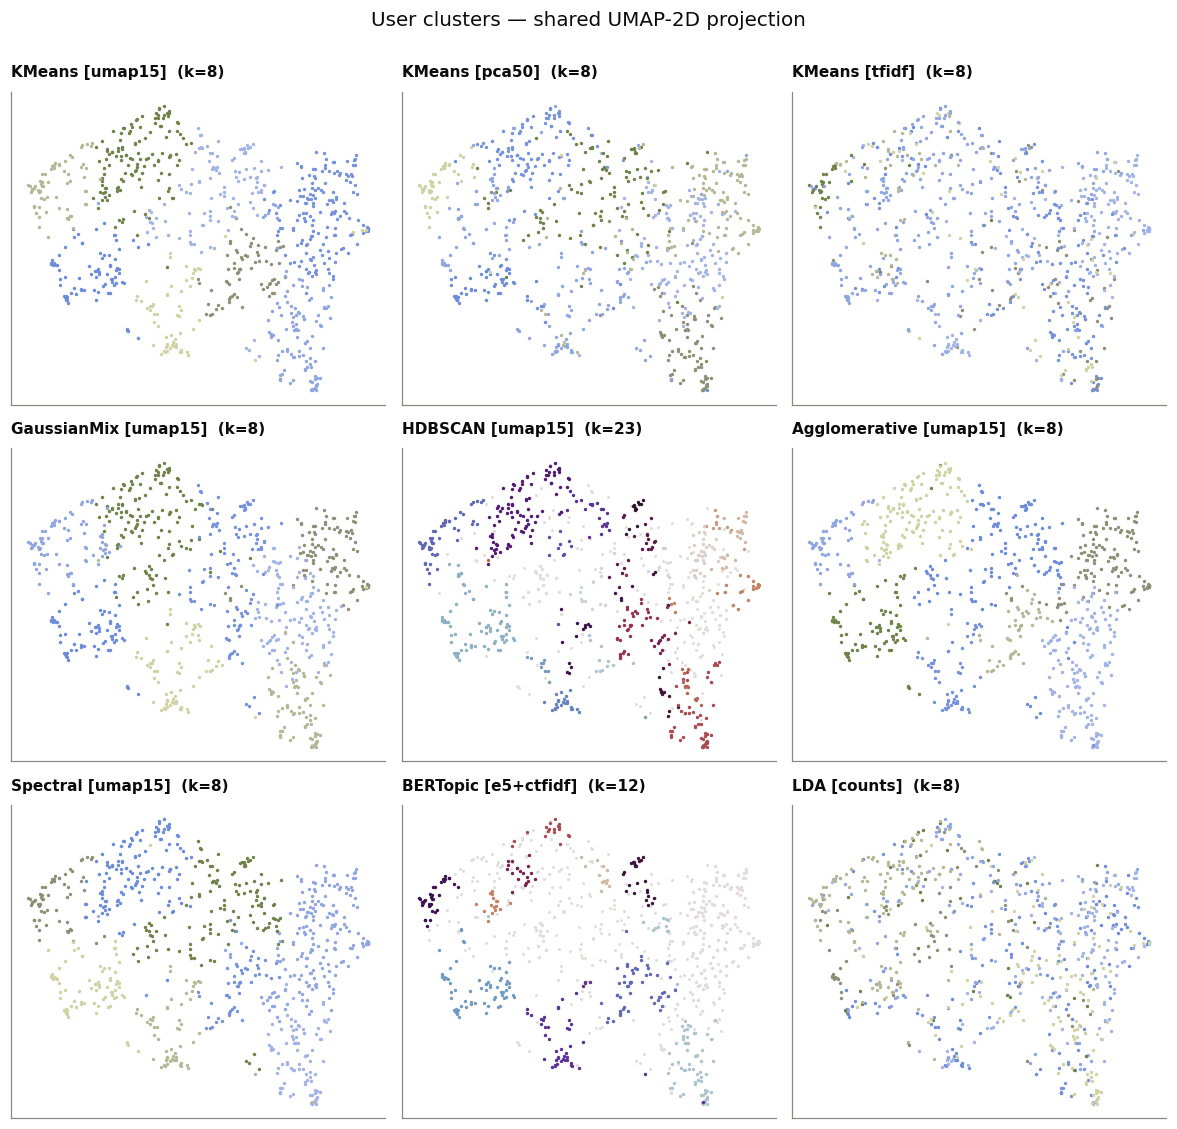

In [22]:
items = list(LABELS_U.items())
ncol = 3; nrow = int(np.ceil(len(items) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 3.6, nrow * 3.4))
for ax, (name, lab) in zip(axes.ravel(), items):
    k = len([u for u in np.unique(lab) if u >= 0])
    plot_clusters(ax, red2_u, lab, f"{name}  (k={k})")
for ax in axes.ravel()[len(items):]:
    ax.axis("off")
fig.suptitle("User clusters — shared UMAP-2D projection", y=1.002, fontsize=13)
plt.tight_layout(); plt.show()

In [23]:
# interpret the best user-level topic method
best_ext_u = board_u.sort_values("ARI", ascending=False).iloc[0]
key_u = f"{best_ext_u['method']} [{best_ext_u['rep']}]"
describe_clusters(LABELS_U[key_u], key_u, users["text"], emb_u, tfidf_u, TFVOCAB_U, users["cs"]);


================  BERTopic [e5+ctfidf]  —  12 clusters shown (of 12)  ================

[0]  n=123  | consensus: legal documentation (0.96)  | terms: colombia, puedo, si, pasaporte, venezuela, ppt, permiso, colombiano
     · Soy venezolano, no tengo pasaporte, tengo un hijo de 2 años nacido en colombia registrado en Co
     · Quisiera saber cómo me puedo regularizar aquí en colombia no tengo pasaporte.. lo único que ten
     · Soy ciudadana venezolana. Ingresé legalmente a Colombia en 2018 con pasaporte y tengo el sello 

[1]  n=78  | consensus: legal documentation (0.76)  | terms: ppt, sacar ppt, sacar, puedo, saber, quiero, si, quiero saber
     · Quiero saber si ya hay tramites para ppt  Deseo los pasos para mi registro para obtener mi ppt 
     · Kiero saber requisitos para sacar el ppt  Dónde lo puedo conseguir  me encuentro en cucuta
     · Quiero saber si aún puedo hacer el trámite para obtener el ppt  Ok muchas gracias y dónde me po

[2]  n=68  | consensus: humanitarian assist

### 7.1 Message-level vs user-level — verdict

In [24]:
def _top(b, col, asc=False):
    r = b.dropna(subset=[col]).sort_values(col, ascending=asc).iloc[0]
    return f"{r['method']} [{r['rep']}] ({r[col]})"
print("                     best silhouette          best topic ARI")
print(f"message level   :   {_top(board,'silhouette'):<24} {_top(board,'ARI')}")
print(f"user level      :   {_top(board_u,'silhouette'):<24} {_top(board_u,'ARI')}")
print()
print("VERDICT")
print("  · Message level gives sharper, more nameable topic clusters (more rows,")
print("    cleaner separation) — best for 'what are people asking about'.")
print("  · User level is coarser (one point per person) — best for segmenting")
print("    profiles/journeys, but weaker topic separation.")
print("  · Same method family wins on each axis at both levels: GaussianMixture/")
print("    LDA for topic agreement, HDBSCAN/BERTopic for granular discovery.")

                     best silhouette          best topic ARI
message level   :   BERTopic [e5+ctfidf] (0.618) GaussianMix [umap15] (0.097)
user level      :   BERTopic [e5+ctfidf] (0.52) BERTopic [e5+ctfidf] (0.222)

VERDICT
  · Message level gives sharper, more nameable topic clusters (more rows,
    cleaner separation) — best for 'what are people asking about'.
  · User level is coarser (one point per person) — best for segmenting
    profiles/journeys, but weaker topic separation.
  · Same method family wins on each axis at both levels: GaussianMixture/
    LDA for topic agreement, HDBSCAN/BERTopic for granular discovery.
